# Emerging Technologies Assessment

**Student:** Hasan Murtaza 


## Problem 1: Generating Random Boolean Functions

### Understanding the Requirements

The [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) works with functions that:
- Accept a fixed number of Boolean inputs (in this case: 4)
- Return a single Boolean output
- Are guaranteed to be either **constant** or **balanced**

With 4 Boolean inputs, we have 2^4 = **16 possible input combinations**.

### Constant vs Balanced Functions

**Constant functions:** Always return the same value
- Always return `False` (0), OR
- Always return `True` (1)
- Total: **2 constant functions**

**Balanced functions:** Return `True` for exactly half the inputs
- Return `True` for exactly 8 of the 16 inputs
- Return `False` for the other 8 inputs
- Total: C(16,8) = **12,870 balanced functions**

In [1]:
# Import required libraries
import random
import numpy as np
import itertools as it
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import pandas as pd
from qiskit_aer import AerSimulator

### Truth Table Representation

Any Boolean function can be represented as a truth table. For a 4-input function:

| Input (binary) | Decimal | Output |
|---------------|---------|--------|
| 0000 | 0 | f(0,0,0,0) |
| 0001 | 1 | f(0,0,0,1) |
| ... | ... | ... |
| 1111 | 15 | f(1,1,1,1) |

We can store the output column as a **tuple of length 16**, where each position corresponds to the decimal value of the binary input.

### Approach

Based on the [notes on random functions](https://github.com/ianmcloughlin/emerging-technologies/blob/main/notes/random-functions.ipynb), I will:

1. Generate a random output tuple (constant or balanced)
2. Create a closure that uses this tuple
3. The closure converts 4 Boolean inputs to an integer index
4. Return the value at that index in the tuple

This approach hides the function's internal structure, making it suitable for testing the Deutsch-Jozsa algorithm.

### Helper Function 1: Generating Random Tuples

The First helper function needed is a function that generates a random tuple representing either a constant or balanced function.

In [2]:
def random_tuple(n):
    """
    Generate a random constant or balanced tuple of length 2**n.
    
    Parameters:
        n (int): Number of input bits
    
    Returns:
        tuple: Length 2**n, either all same value (constant) or half 0s/1s (balanced)
    """
    # Randomly choose function type (50/50 probability)
    ftype = random.choice(['constant', 'balanced'])
    
    if ftype == 'constant':
        # Choose all 0s or all 1s
        zero_or_one = random.choice([0, 1])
        # Create tuple by repeating the value 2**n times
        t = (zero_or_one,) * (2**n)
    else:  # balanced
        # Create list with half 0s, half 1s
        t = ([0] * (2**(n-1))) + ([1] * (2**(n-1)))
        # Shuffle to randomize positions
        random.shuffle(t)
        # Convert to immutable tuple
        t = tuple(t)
    
    return t

### Understanding Tuple Multiplication

The expression `(value,) * n` creates a tuple by repeating `value` n times. The comma after `value` is crucial, it makes it a tuple, not just a parenthesized expression.

In [3]:
# Example: Create tuple of 8 zeros
zeros = (0,) * 8
print(f"Eight zeros: {zeros}")

# Example: Create tuple of 8 ones  
ones = (1,) * 8
print(f"Eight ones: {ones}") 

Eight zeros: (0, 0, 0, 0, 0, 0, 0, 0)
Eight ones: (1, 1, 1, 1, 1, 1, 1, 1)


### Testing random_tuple



In [4]:
# Generate some random tuples for n=4 (16 elements)
print("Random tuples for n=4:")
for i in range(5):
    t = random_tuple(4)
    # Count ones to check if constant or balanced
    ones_count = sum(t)
    if ones_count == 0 or ones_count == 16:
        ftype = "constant"
    else:
        ftype = "balanced"
    print(f"{t} - {ftype} ({ones_count} ones)")

Random tuples for n=4:
(1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0) - balanced (8 ones)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) - constant (0 ones)
(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1) - constant (16 ones)
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0) - constant (0 ones)
(0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1) - balanced (8 ones)


### Helper Function 2: Converting Binary Arguments to Integer

We need to convert 4 Boolean arguments (e.g., `1, 0, 1, 1`) into an integer index (e.g., 11 in decimal = 1011 in binary).

Python's **variadic function** syntax (`*args`) allows us to accept any number of arguments. See [Real Python's guide on *args](https://realpython.com/python-boolean/) for more details.

In [5]:
def bin_args_to_int(*args):
    """
    Convert binary arguments to an integer.
    
    Parameters:
        *args: Variable number of binary values (0/1 or False/True)
    
    Returns:
        int: Decimal representation of the binary input
    """
    # Convert any truthy values to '1', falsy to '0'
    bits = ['1' if i else '0' for i in args]
    # Join into binary string
    bits_str = ''.join(bits)
    # Convert binary string to integer (base 2)
    return int(bits_str, 2)

### Testing Binary Conversion

Verify this works correctly:

In [6]:
# Test binary to integer conversion
print(f"Binary 0000 = {bin_args_to_int(0, 0, 0, 0)}")
print(f"Binary 0001 = {bin_args_to_int(0, 0, 0, 1)}")
print(f"Binary 1011 = {bin_args_to_int(1, 0, 1, 1)}")
print(f"Binary 1111 = {bin_args_to_int(1, 1, 1, 1)}")

Binary 0000 = 0
Binary 0001 = 1
Binary 1011 = 11
Binary 1111 = 15


### Main Function: random_constant_balanced

Now we combine everything using a **closure**. A closure is a function defined inside another function that "remembers" variables from its enclosing scope.

See [Real Python's guide on closures](https://realpython.com/python-closures/) for more information on this pattern.

In [7]:
def random_constant_balanced():
    """
    Return a random constant or balanced function taking 4 Boolean inputs.
    
    Returns:
        function: A closure that implements the random function
    """
    # Generate random output tuple for n=4 (length 16)
    output_tuple = random_tuple(4)
    
    # Define inner function that uses the tuple
    def f(*args):
        # Ensure exactly 4 arguments
        if len(args) != 4:
            raise ValueError(f"Expected 4 arguments, got {len(args)}")
        
        # Convert binary args to index (0-15)
        index = bin_args_to_int(*args)
        
        # Return value at that index
        return output_tuple[index]
    
    return f

### Why Use a Closure?

The closure pattern is important because:
1. It **hides the output tuple** from external inspection
2. The function appears "black box" to outside code
3. This matches how the Deutsch-Jozsa algorithm works, it queries the function without knowing its internal structure

Attempting to inspect the function won't reveal whether it's constant or balanced:

In [8]:
# Create a random function
f = random_constant_balanced()

# if we try to inspect it, we can't tell what it does.
print(f"Function object: {f}")
print(f"Function name: {f.__name__}")

Function object: <function random_constant_balanced.<locals>.f at 0x75883c1e2ac0>
Function name: f


### Testing the Function

Test the function by calling it with various inputs:

In [9]:
# Create a random function
f = random_constant_balanced()

# Test with a few inputs
print("Testing random function:")
print(f"f(0,0,0,0) = {f(0,0,0,0)}")
print(f"f(0,0,0,1) = {f(0,0,0,1)}")
print(f"f(1,0,1,1) = {f(1,0,1,1)}")
print(f"f(1,1,1,1) = {f(1,1,1,1)}")

Testing random function:
f(0,0,0,0) = 0
f(0,0,0,1) = 0
f(1,0,1,1) = 0
f(1,1,1,1) = 0


### Complete Testing: All 16 Inputs

To verify the function works correctly, let's test all 16 possible inputs and check if it's truly constant or balanced:

In [10]:
# Create a random function
f = random_constant_balanced()

# Generate all 16 possible 4-bit inputs
all_inputs = it.product([0, 1], repeat=4)

# Test function on all inputs
results = []
print("Input (binary) | Decimal | Output")
print("-" * 35)
for inp in all_inputs:
    output = f(*inp)
    results.append(output)
    binary = ''.join(str(b) for b in inp)
    decimal = bin_args_to_int(*inp)
    print(f"{binary:14} | {decimal:7} | {output}")

# Determine function type
ones_count = sum(results)
if ones_count == 0 or ones_count == 16:
    print(f"\nFunction is CONSTANT (all {'0' if ones_count == 0 else '1'}s)")
elif ones_count == 8:
    print(f"\nFunction is BALANCED (8 ones, 8 zeros)")
else:
    print(f"\nERROR: Function is neither constant nor balanced")

Input (binary) | Decimal | Output
-----------------------------------
0000           |       0 | 1
0001           |       1 | 1
0010           |       2 | 0
0011           |       3 | 0
0100           |       4 | 1
0101           |       5 | 0
0110           |       6 | 1
0111           |       7 | 0
1000           |       8 | 1
1001           |       9 | 0
1010           |      10 | 0
1011           |      11 | 1
1100           |      12 | 0
1101           |      13 | 1
1110           |      14 | 1
1111           |      15 | 0

Function is BALANCED (8 ones, 8 zeros)


### Verification: Multiple Random Functions

We should generate several random functions to confirm they're all properly constant or balanced:

In [11]:
# Test 10 random functions
print("Testing 10 random functions:")
print("-" * 40)

for i in range(10):
    # Create random function
    f = random_constant_balanced()
    
    # Test on all inputs
    all_inputs = it.product([0, 1], repeat=4)
    results = [f(*inp) for inp in all_inputs]
    ones_count = sum(results)
    
    # Classify
    if ones_count == 0:
        ftype = "constant (all 0s)"
    elif ones_count == 16:
        ftype = "constant (all 1s)"
    elif ones_count == 8:
        ftype = "balanced"
    else:
        ftype = "ERROR"
    
    print(f"Function {i+1}: {ones_count:2} ones - {ftype}")

Testing 10 random functions:
----------------------------------------
Function 1:  8 ones - balanced
Function 2:  0 ones - constant (all 0s)
Function 3: 16 ones - constant (all 1s)
Function 4:  8 ones - balanced
Function 5:  8 ones - balanced
Function 6:  0 ones - constant (all 0s)
Function 7:  8 ones - balanced
Function 8:  0 ones - constant (all 0s)
Function 9:  8 ones - balanced
Function 10:  8 ones - balanced


### Summary

We have successfully implemented `random_constant_balanced()` which:
- Returns a function taking 4 Boolean inputs
- Randomly chooses between constant and balanced functions
- Uses closures to hide the internal structure
- Properly implements the required behavior

This function will be used in Problem 2 to test classical approaches and in Problem 5 to test the quantum Deutsch-Jozsa algorithm.

## Problem 2: Classical Testing for Function Type.

### Understanding the Classical Approach

To determine if a function is constant or balanced classically, we need to query the function (call it with inputs) and observe the outputs.

**Key Analysis:**
- For a 4-bit function, there are 16 possible inputs
- **Constant function:** All 16 outputs are the same
- **Balanced function:** Exactly 8 outputs are 1, and 8 are 0

**Worst-case scenario:**
- To be 100% certain a function is **constant**, we must check all 16 inputs
- To be 100% certain a function is **balanced**, we need at most 9 inputs:
  - If first 8 outputs are all the same, function might be constant
  - The 9th output determines it: if different -> balanced, if same -> need to check all to confirm constant

**For general n-bit functions:**
- Worst case: 2^n queries (to confirm constant)
- Best case: 2 queries (to detect balanced)

### Implementation Strategy

Following the approach from the [course notes](https://github.com/ianmcloughlin/emerging-technologies/blob/main/notes/random-functions.ipynb):

1. Generate all 16 possible 4-bit inputs using `itertools.product`
2. Call function `f` with each input.
3. Collect all outputs into an array.
4. Analyze outputs:
- If all outputs are 0 OR all outputs are 1 -> constant
- If exactly 8 outputs are 1 -> balanced

In [12]:
def determine_constant_balanced(f):
    """
    Determine if a function is constant or balanced.
    
    Uses the classical approach: test the function on all possible inputs.
    
    Parameters:
        f: Function taking 4 Boolean inputs, returning Boolean output
    
    Returns:
        str: Either "constant" or "balanced"
    """
    # Generate all 16 possible 4-bit inputs
    all_inputs = it.product([0, 1], repeat=4)
    
    # Test function on all inputs
    results = [f(*inp) for inp in all_inputs]
    
    # Convert to numpy array for analysis
    results = np.array(results)
    
    # Check if constant (all 0s or all 1s)
    if np.all(results == 0) or np.all(results == 1):
        return "constant"
    # Check if balanced (exactly 8 ones)
    elif results.sum() == 8:
        return "balanced"
    else:
        # Shouldnt happen with valid Problem 1 functions
        raise ValueError("Function is neither constant nor balanced")

### Efficiency Analysis

**Queries required:**
- Our implementation: **16 function calls** (tests all inputs)
- Guarantees 100% certainty in all cases
- Time complexity: O(2^n) where n = 4

**Maximum queries needed:**
For a 4-bit function, the maximum number of queries needed to be **100% certain** is:
- **16 queries** (worst case: must check all inputs to confirm constant)
- **9 queries minimum** to detect balanced (if first 8 are same, 9th determines it)

This will be contrasted with the quantum approach in Problems 4 and 5, where [Deutschs algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) can determine the answer with just **1 query**.

In [13]:
# Test with random functions from Problem 1
print("Testing determine_constant_balanced:\n")

for i in range(10):
    # Generate random function
    f = random_constant_balanced()
    
    # Determine its type
    result = determine_constant_balanced(f)
    
    print(f"Function {i+1}: {result}")

Testing determine_constant_balanced:

Function 1: balanced
Function 2: balanced
Function 3: balanced
Function 4: balanced
Function 5: constant
Function 6: balanced
Function 7: balanced
Function 8: constant
Function 9: constant
Function 10: constant


### Verification: Manual Cross-Check

To verify our function works correctly, manually check one function by examining all its outputs:

In [14]:
# Create a random function
f = random_constant_balanced()

# Use our function to determine type
determined_type = determine_constant_balanced(f)

# Manually verify
all_inputs = it.product([0, 1], repeat=4)
outputs = [f(*inp) for inp in all_inputs]
ones_count = sum(outputs)

# Manual classification
if ones_count == 0 or ones_count == 16:
    manual_type = "constant"
else:
    manual_type = "balanced"

print(f"Determined type: {determined_type}")
print(f"Manual check: {manual_type}")
print(f"Ones count: {ones_count}/16")
print(f"Match: {determined_type == manual_type}")

Determined type: constant
Manual check: constant
Ones count: 16/16
Match: True


### Optimized Version: Early Stopping

We can create an optimized version that stops as soon as it detects the function is balanced:

In [15]:
def determine_constant_balanced_optimized(f):
    """
    Optimized version with early stopping.
    
    Checks inputs one at a time and stops when balanced is detected.
    
    Best case: 2 queries (immediate difference found)
    Worst case: 16 queries (all same, confirming constant)
    """
    # Get all inputs as a list
    inputs = list(it.product([0, 1], repeat=4))
    
    # Get first output
    first_output = f(*inputs[0])
    
    # Check remaining inputs
    for inp in inputs[1:]:
        output = f(*inp)
        # If different from first, its balanced
        if output != first_output:
            return "balanced"
    
    # All same, must be constant
    return "constant"

In [16]:
# Compare both versions
print("Comparing regular vs optimized versions:\n")

for i in range(5):
    # Generate random function
    f = random_constant_balanced()
    
    # Test both
    result1 = determine_constant_balanced(f)
    result2 = determine_constant_balanced_optimized(f)
    
    # Verify they match
    match = "Yes Match" if result1 == result2 else "Not match"
    print(f"Function {i+1}: {result1:8} vs {result2:8} {match}")

Comparing regular vs optimized versions:

Function 1: constant vs constant Yes Match
Function 2: balanced vs balanced Yes Match
Function 3: balanced vs balanced Yes Match
Function 4: constant vs constant Yes Match
Function 5: constant vs constant Yes Match


### Answer: Maximum Number of Queries

**Question:** What is the maximum number of times you need to call `f` to be 100% certain whether it is constant or balanced?

**Answer:** **16 queries** (for 4-bit functions)

**Reasoning:**
- To detect a **balanced** function: minimum 2 queries (find one difference), maximum 9 queries
- To confirm a **constant** function: must check **all 16 inputs**
- Since we don't know in advance which type it is, worst case is confirming constant = **16 queries**

**General case (n-bit functions):**
- Maximum queries needed: **2^n**
- This is exponential in the number of input bits

**Why this matters:**
As explained in [Quanta Magazine's article on quantum supremacy](https://www.quantamagazine.org/john-preskill-explains-quantum-supremacy-20191002/), this exponential classical cost is what makes quantum algorithms valuable. The Deutsch-Jozsa algorithm solves this with just **1 quantum query**, regardless of n!

### Summary

We have implemented `determine_constant_balanced()` which:
- Takes a function `f` from Problem 1 as input
- Returns `"constant"` or `"balanced"` with 100% certainty
- Requires **16 queries** in the worst case (exponential: O(2^n))

**Key findings:**
- Classical approach: Must query function up to 2^n times
- Optimized approach: Can stop early for balanced (best case: 2 queries)
- Worst case: Still 2^n queries to confirm constant

This classical complexity sets the baseline for understanding the quantum advantage demonstrated in Problems 4 and 5, where the quantum approach needs only **1 evaluation**.

## Problem 3: Quantum Oracles

### Problem Statement

[Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm) is the simplest example of a quantum algorithm using superposition to determine a global property of a function with a single evaluation. In the single-input case, there are four possible Boolean functions.

The task is to use Qiskit to create the appropriate **quantum oracles** for each of the possible single-Boolean-input functions used in Deutsch's algorithm, demonstrate their use, and explain how each oracle implements its corresponding function.

### Understanding Quantum Oracles

A [quantum oracle](https://quantumcomputing.stackexchange.com/questions/4625/what-exactly-is-an-oracle/4626#4626) is a "black box" operation that implements a classical function in a quantum circuit. 

**Key properties:**
- Must be reversible (unitary operation)
- Implements a classical function f(x) in quantum form
- Uses the pattern: |x⟩|y⟩ → |x⟩|y ⊕ f(x)⟩

**Why this pattern?**
- Direct mapping |x⟩ -> |f(x)⟩ is not always reversible
- Extra "ancilla" qubit holds the result
- XOR (⊕) operation is reversible: (y ⊕ f(x)) ⊕ f(x) = y

**In our circuits:**
- Qubit 0: Input bit x
- Qubit 1: Ancilla bit y (starts as 0 or 1)
- After oracle: Qubit 1 becomes y ⊕ f(x)

### The Four Single-Bit Boolean Functions

For Deutsch's algorithm with a single input bit, there are exactly [four possible functions](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm):

**Constant Functions:**
- **f₁(x) = 0**: Always returns 0
- **f₄(x) = 1**: Always returns 1

**Balanced Functions:**
- **f₂(x) = x**: Returns the input (identity)
- **f₃(x) = ¬x**: Returns the opposite of input (negation)

Each function can be represented as a truth table:

| x | f₁(x) | f₂(x) | f₃(x) | f₄(x) |
|---|-------|-------|-------|-------|
| 0 |   0   |   0   |   1   |   1   |
| 1 |   0   |   1   |   0   |   1   |

We will implement a quantum oracle for each of these functions.

### Oracle Implementation Strategy

Following the approach from the [course notes](https://github.com/ianmcloughlin/emerging-technologies/blob/main/notes/deutsch.ipynb), each oracle is implemented as a quantum circuit with 2 qubits.

**General pattern:**
1. Create a quantum circuit with 2 qubits
2. Apply gates to implement |y ⊕ f(x)⟩
3. The gates depend on the function f(x)

**Gate choices:**
- **No gates**: f(x) = 0 (y ⊕ 0 = y, no change)
- **X gate**: f(x) = 1 (y ⊕ 1 = ¬y, always flip)
- **CNOT gate**: f(x) = x (controlled flip based on x)
- **X + CNOT**: f(x) = ¬x (combination)

### Oracle 1: Constant-0 Function

**Function:** f₁(x) = 0

**Truth table:**
- f(0) = 0
- f(1) = 0

**Implementation:**
- No gates needed!
- Since f(x) = 0 for all x, we have y ⊕ 0 = y
- The ancilla qubit remains unchanged

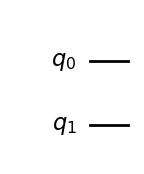

In [17]:
# Oracle for f₁(x) = 0 (constant-0)
oracle_f1 = QuantumCircuit(2, name='f₁')

# No gates needed - identity operation
# y ⊕ f(x) = y ⊕ 0 = y

# Visualize
oracle_f1.draw('mpl')

### Oracle 2: Identity Function

**Function:** f₂(x) = x

**Truth table:**
- f(0) = 0
- f(1) = 1

**Implementation:**
- CNOT gate with control on qubit 0, target on qubit 1
- When x=0: f(x)=0, so y ⊕ 0 = y (no flip)
- When x=1: f(x)=1, so y ⊕ 1 = ¬y (flip)
- This is exactly what CNOT does.

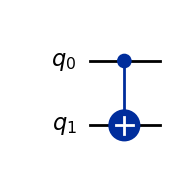

In [18]:
# Oracle for f₂(x) = x (identity)
oracle_f2 = QuantumCircuit(2, name='f₂')

# CNOT: control on qubit 0, target on qubit 1
oracle_f2.cx(0, 1)

# Visualize
oracle_f2.draw('mpl')

### Oracle 3: Negation Function

**Function:** f₃(x) = ¬x

**Truth table:**
- f(0) = 1
- f(1) = 0

**Implementation:**
- X gate on qubit 1, then CNOT
- Alternative: CNOT then X (same result)
- When x=0: f(x)=1, need to flip qubit 1
- When x=1: f(x)=0, need to keep qubit 1 same
- X gate flips unconditionally, CNOT conditionally

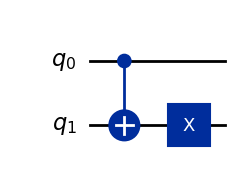

In [19]:
# Oracle for f₃(x) = ¬x (negation)
oracle_f3 = QuantumCircuit(2, name='f₃')

# CNOT then X
oracle_f3.cx(0, 1)
oracle_f3.x(1)

# Visualize
oracle_f3.draw('mpl')

### Oracle 4: Constant-1 Function

**Function:** f₄(x) = 1

**Truth table:**
- f(0) = 1
- f(1) = 1

**Implementation:**
- X gate on qubit 1 only
- Since f(x) = 1 for all x, we have y ⊕ 1 = ¬y
- Always flip the ancilla qubit regardless of input

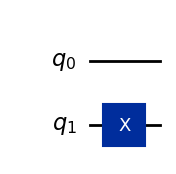

In [20]:
# Oracle for f₄(x) = 1 (constant-1)
oracle_f4 = QuantumCircuit(2, name='f₄')

# X gate on qubit 1
oracle_f4.x(1)

# Visualize
oracle_f4.draw('mpl')

### Testing the Oracles

To verify each oracle works correctly, test them on all possible input states:
- |00⟩: x=0, y=0
- |01⟩: x=0, y=1
- |10⟩: x=1, y=0
- |11⟩: x=1, y=1

For each oracle, the second qubit should become y ⊕ f(x).

In [21]:
def test_oracle(oracle, function_name):
    """
    Test an oracle on all 4 basis states.
    
    Parameters:
        oracle: QuantumCircuit implementing the oracle
        function_name: Name of the function (for display)
    """
    print(f"\nTesting {function_name}:")
    print("Input  | Output | Expected (y ⊕ f(x))")
    print("-" * 40)
    
    # Test all 4 basis states
    for x in [0, 1]:
        for y in [0, 1]:
            # Create circuit with initial state |xy⟩
            qc = QuantumCircuit(2)
            if x == 1:
                qc.x(0)  # Set qubit 0 to |1⟩
            if y == 1:
                qc.x(1)  # Set qubit 1 to |1⟩
            
            # Apply oracle
            qc.compose(oracle, inplace=True)
            
            # Get final state
            state = Statevector.from_instruction(qc)
            
            # Find which basis state has probability 1
            for i, amplitude in enumerate(state):
                if abs(amplitude) > 0.99:  # Close to 1
                    # Convert index to binary
                    result = format(i, '02b')
                    x_out = int(result[1])
                    y_out = int(result[0])
                    
            print(f"|{x}{y}⟩   | |{x_out}{y_out}⟩   | x={x_out}, y'={y_out}")

# Test all oracles
test_oracle(oracle_f1, "f₁(x) = 0")
test_oracle(oracle_f2, "f₂(x) = x")
test_oracle(oracle_f3, "f₃(x) = ¬x")
test_oracle(oracle_f4, "f₄(x) = 1")


Testing f₁(x) = 0:
Input  | Output | Expected (y ⊕ f(x))
----------------------------------------
|00⟩   | |00⟩   | x=0, y'=0
|01⟩   | |01⟩   | x=0, y'=1
|10⟩   | |10⟩   | x=1, y'=0
|11⟩   | |11⟩   | x=1, y'=1

Testing f₂(x) = x:
Input  | Output | Expected (y ⊕ f(x))
----------------------------------------
|00⟩   | |00⟩   | x=0, y'=0
|01⟩   | |01⟩   | x=0, y'=1
|10⟩   | |11⟩   | x=1, y'=1
|11⟩   | |10⟩   | x=1, y'=0

Testing f₃(x) = ¬x:
Input  | Output | Expected (y ⊕ f(x))
----------------------------------------
|00⟩   | |01⟩   | x=0, y'=1
|01⟩   | |00⟩   | x=0, y'=0
|10⟩   | |10⟩   | x=1, y'=0
|11⟩   | |11⟩   | x=1, y'=1

Testing f₄(x) = 1:
Input  | Output | Expected (y ⊕ f(x))
----------------------------------------
|00⟩   | |01⟩   | x=0, y'=1
|01⟩   | |00⟩   | x=0, y'=0
|10⟩   | |11⟩   | x=1, y'=1
|11⟩   | |10⟩   | x=1, y'=0


### Verification Against Truth Tables

Verify each oracle produces the correct output according to its truth table:

**For f₁(x) = 0:**
- Input |00⟩ -> Output |00⟩ (y=0, f(0)=0, 0⊕0=0) ✓
- Input |10⟩ -> Output |10⟩ (y=0, f(1)=0, 0⊕0=0) ✓

**For f₂(x) = x:**
- Input |00⟩ -> Output |00⟩ (y=0, f(0)=0, 0⊕0=0) ✓
- Input |10⟩ -> Output |11⟩ (y=0, f(1)=1, 0⊕1=1) ✓

**For f₃(x) = ¬x:**
- Input |00⟩ -> Output |01⟩ (y=0, f(0)=1, 0⊕1=1) ✓
- Input |10⟩ -> Output |10⟩ (y=0, f(1)=0, 0⊕0=0) ✓

**For f₄(x) = 1:**
- Input |00⟩ -> Output |01⟩ (y=0, f(0)=1, 0⊕1=1) ✓
- Input |10⟩ -> Output |11⟩ (y=0, f(1)=1, 0⊕1=1) ✓

In [22]:
# Create a comprehensive truth table verification
def verify_oracle_truth_table(oracle, f_values, name):
    """
    Verify oracle against expected function values.
    
    Parameters:
        oracle: QuantumCircuit
        f_values: Dictionary {0: f(0), 1: f(1)}
        name: Function name
    """
    results = []
    
    for x in [0, 1]:
        for y in [0, 1]:
            # Create initial state
            qc = QuantumCircuit(2)
            if x == 1:
                qc.x(0)
            if y == 1:
                qc.x(1)
            
            # Apply oracle
            qc.compose(oracle, inplace=True)
            
            # Get result
            state = Statevector.from_instruction(qc)
            for i, amp in enumerate(state):
                if abs(amp) > 0.99:
                    result_bits = format(i, '02b')
                    y_out = int(result_bits[0])
            
            # Calculate expected
            expected = y ^ f_values[x]  # y XOR f(x)
            match = "✓" if y_out == expected else "X"
            
            results.append({
                'x': x,
                'y': y,
                'f(x)': f_values[x],
                'y⊕f(x)': expected,
                'Result': y_out,
                'Match': match
            })
    
    df = pd.DataFrame(results)
    print(f"\n{name} Truth Table Verification:")
    print(df.to_string(index=False))
    return df

# Verify all oracles
verify_oracle_truth_table(oracle_f1, {0: 0, 1: 0}, "f₁(x) = 0")
verify_oracle_truth_table(oracle_f2, {0: 0, 1: 1}, "f₂(x) = x")
verify_oracle_truth_table(oracle_f3, {0: 1, 1: 0}, "f₃(x) = ¬x")
verify_oracle_truth_table(oracle_f4, {0: 1, 1: 1}, "f₄(x) = 1")


f₁(x) = 0 Truth Table Verification:
 x  y  f(x)  y⊕f(x)  Result Match
 0  0     0       0       0     ✓
 0  1     0       1       1     ✓
 1  0     0       0       0     ✓
 1  1     0       1       1     ✓

f₂(x) = x Truth Table Verification:
 x  y  f(x)  y⊕f(x)  Result Match
 0  0     0       0       0     ✓
 0  1     0       1       1     ✓
 1  0     1       1       1     ✓
 1  1     1       0       0     ✓

f₃(x) = ¬x Truth Table Verification:
 x  y  f(x)  y⊕f(x)  Result Match
 0  0     1       1       1     ✓
 0  1     1       0       0     ✓
 1  0     0       0       0     ✓
 1  1     0       1       1     ✓

f₄(x) = 1 Truth Table Verification:
 x  y  f(x)  y⊕f(x)  Result Match
 0  0     1       1       1     ✓
 0  1     1       0       0     ✓
 1  0     1       1       1     ✓
 1  1     1       0       0     ✓


,x,y,f(x),y⊕f(x),Result,Match
0,0,0,1,1,1,✓
1,0,1,1,0,0,✓
2,1,0,1,1,1,✓
3,1,1,1,0,0,✓


### How Each Oracle Works

**f₁ (Constant-0):**
- No gates = identity operation
- Output qubit unchanged: y ⊕ 0 = y
- Simplest oracle possible

**f₂ (Identity):**
- CNOT gate implements conditional XOR
- Control qubit (x) determines if target flips
- When x=1, flips target (y ⊕ 1 = ¬y)

**f₃ (Negation):**
- CNOT flips when x=1
- X gate flips unconditionally
- Combined: implements y ⊕ ¬x
- Alternative implementation: X then CNOT

**f₄ (Constant-1):**
- X gate always flips target
- Output: y ⊕ 1 = ¬y regardless of x
- Complements the ancilla qubit

Each oracle correctly implements the XOR pattern |x⟩|y⟩ → |x⟩|y ⊕ f(x)⟩ as required for Deutsch's algorithm.

### Summary

Successfully implemented quantum oracles for all four single-Boolean-input functions:

**Implementation:**
- **f₁(x) = 0**: No gates (identity)
- **f₂(x) = x**: CNOT gate
- **f₃(x) = ¬x**: CNOT + X gates
- **f₄(x) = 1**: X gate only

**Key insights:**
- All oracles use the reversible pattern |x⟩|y⟩ -> |x⟩|y ⊕ f(x)⟩
- Input qubit (qubit 0) remains unchanged
- Ancilla qubit (qubit 1) stores y ⊕ f(x)
- Different gate combinations implement different functions

These oracles will be used in Problem 4 to demonstrate Deutschs algorithm, which can determine whether a function is constant or balanced with just **one** quantum query, compared to **two** classical queries required in Problem 2.

## Problem 4: Deutsch's Algorithm with Qiskit.

### Problem Statement

Use [Qiskit](https://www.ibm.com/quantum/qiskit) to design a quantum circuit that solves Deutsch's problem for a function with a single Boolean input. 

**Task:**
- Implement the necessary circuit
- Demonstrate its use with each quantum oracle from Problem 3
- Describe how the interference pattern allows determining whether the function is constant or balanced using only **one query** to the oracle

This demonstrates a key quantum advantage: solving a problem with fewer queries than any classical algorithm.

### Understanding Deutsch's Algorithm

[Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/introduction) is historically significant as one of the first examples of quantum speedup over classical computation.

**The Problem:**
- Given: A black-box function f(x) with 1-bit input and 1-bit output
- Question: Is f constant (same output for all inputs) or balanced (different outputs for different inputs)?

**Classical Solution:**
- Must query the function **2 times** (test both inputs)
- Worst case: 2 queries to be certain

**Quantum Solution:**
- Query the function **1 time** (in superposition)
- Uses quantum interference to reveal global property
- Guaranteed correct answer with 1 query

**The Key Insight:**
Rather than checking individual inputs, we can query the function on a **superposition** of all inputs simultaneously and use interference to extract global information.

### The Deutsch Circuit

Following the approach from the [course notes](https://github.com/ianmcloughlin/emerging-technologies/blob/main/notes/deutsch.ipynb), the circuit structure is:

```
q₀: ─H─┤ Oracle ├─H─M─
        │        │
q₁: ─X─H┤ Oracle ├────
```

**Circuit Steps:**
1. **Initialize ancilla:** Apply X gate to q₁ to set it to |1⟩
2. **Create superposition:** Apply H gates to both qubits
3. **Query oracle:** Apply the oracle (from Problem 3)
4. **Interference:** Apply H gate to q₀
5. **Measure:** Measure q₀

**Reading the Result:**
- Measurement = **|0⟩** → Function is **constant**
- Measurement = **|1⟩** → Function is **balanced**

The measurement outcome directly tells us the global property of the function.

### Why It Works: Phase Kickback

The magic happens through a phenomenon called **phase kickback**.

**Key Steps:**

1. **After H gates:**
   - q₀ is in superposition: |+⟩ = (|0⟩ + |1⟩)/√2
   - q₁ is in superposition: |−⟩ = (|0⟩ - |1⟩)/√2

2. **Oracle application:**
   - For |−⟩ state, the oracle creates a **phase flip** instead of bit flip
   - Constant function: No relative phase introduced
   - Balanced function: Introduces (-1) phase on one component

3. **Final H gate:**
   - Converts phase information back to computational basis
   - Interference causes different outcomes for constant vs balanced

The ancilla qubit (q₁) in the |−⟩ state causes the oracle to "kick back" phase information to q₀, which is then revealed by the final Hadamard gate.

In [23]:
def deutsch_algorithm(oracle):
    """
    Implement Deutsch's algorithm for a given oracle.
    
    Parameters:
        oracle: QuantumCircuit (2 qubits) implementing the function
    
    Returns:
        str: "constant" or "balanced"
    """
    # Create circuit: 2 qubits, 1 classical bit
    qc = QuantumCircuit(2, 1)
    
    # Step 1: Initialize q₁ to |1⟩
    qc.x(1)
    
    # Step 2: Apply Hadamard to both qubits
    qc.h([0, 1])
    
    # Add barrier for visualization
    qc.barrier()
    
    # Step 3: Apply oracle
    qc.compose(oracle, inplace=True)
    
    # Add barrier
    qc.barrier()
    
    # Step 4: Apply Hadamard to q₀
    qc.h(0)
    
    # Step 5: Measure q₀
    qc.measure(0, 0)
    
    return qc

### Testing with All Four Oracles

Test Deutsch's algorithm with each oracle from Problem 3:
- f₁(x) = 0 (constant) -> Expect: |0⟩
- f₂(x) = x (balanced) -> Expect: |1⟩
- f₃(x) = ¬x (balanced) ->Expect: |1⟩
- f₄(x) = 1 (constant) -> Expect: |1⟩

Wait, f₄ is constant but returns 1 always. Let's verify

In [24]:
def run_deutsch(oracle, name, expected_type):
    """
    Run Deutsch's algorithm and display results.
    
    Parameters:
        oracle: The oracle circuit
        name: Name of the function
        expected_type: "constant" or "balanced"
    """
    # Build the circuit
    qc = deutsch_algorithm(oracle)
    
    # Simulate
    simulator = AerSimulator()
    result = simulator.run(qc, shots=1000).result()
    counts = result.get_counts()
    
    # Interpret result
    if '0' in counts and counts['0'] > 900:
        measured_type = "constant"
    else:
        measured_type = "balanced"
    
    # Check if correct
    match = "✓" if measured_type == expected_type else "✗"
    
    print(f"{name}:")
    print(f"  Expected: {expected_type}")
    print(f"  Measured: {measured_type} {match}")
    print(f"  Counts: {counts}")
    print()
    
    return qc, counts

# Test all four oracles
print("Testing Deutsch's Algorithm:\\n")

qc1, _ = run_deutsch(oracle_f1, "f₁(x) = 0", "constant")
qc2, _ = run_deutsch(oracle_f2, "f₂(x) = x", "balanced")
qc3, _ = run_deutsch(oracle_f3, "f₃(x) = ¬x", "balanced")
qc4, _ = run_deutsch(oracle_f4, "f₄(x) = 1", "constant")

Testing Deutsch's Algorithm:\n
f₁(x) = 0:
  Expected: constant
  Measured: constant ✓
  Counts: {'0': 1000}

f₂(x) = x:
  Expected: balanced
  Measured: balanced ✓
  Counts: {'1': 1000}

f₃(x) = ¬x:
  Expected: balanced
  Measured: balanced ✓
  Counts: {'1': 1000}

f₄(x) = 1:
  Expected: constant
  Measured: constant ✓
  Counts: {'0': 1000}



### Visualizing a Complete Circuit

Visualize the complete Deutsch circuit for one of the oracles:

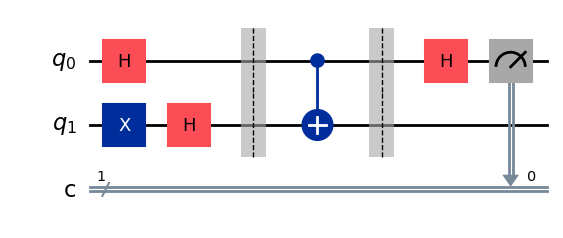

In [25]:
# Visualize Deutsch circuit with f₂ (identity) oracle
qc2.draw('mpl')

### Comparison with Classical Approach

Let's compare the quantum and classical approaches:

| Aspect | Classical (Problem 2) | Quantum (Deutsch) |
|--------|----------------------|-------------------|
| **Queries needed** | 2 | 1 |
| **Worst case** | Must test both inputs | Always 1 query |
| **How it works** | Test f(0) and f(1) individually | Test superposition of inputs |
| **Information gained** | Individual outputs | Global property |

**Quantum Advantage:**
- **50% reduction** in queries for single-bit case
- For n-bit functions (Deutsch-Jozsa): exponential advantage.
  - Classical: 2^(n-1) + 1 queries worst case
  - Quantum: **1 query** regardless of n

This demonstrates the power of quantum parallelism and interference.

### Detailed Analysis: Why Each Oracle Works

Let's trace through what happens for each oracle type:

**Constant Functions (f₁, f₄):**

After the oracle is applied:
- The superposition has **no relative phase** between |0⟩ and |1⟩ components
- Final H gate recombines them constructively to |0⟩
- Measurement gives |0⟩ -> constant

**Balanced Functions (f₂, f₃):**

After the oracle is applied:
- A **relative phase of (-1)** is introduced between components
- Final H gate recombines them destructively to |1⟩
- Measurement gives |1⟩ -> balanced

The phase kickback mechanism converts the functions global property into a measurable phase difference.

In [26]:
#verify the mathematics for one case
# Show state evolution for f₂ (identity)

def show_state_evolution(oracle_name, oracle):
    """Show quantum state at each step."""
    print(f"State Evolution for {oracle_name}:\\n")
    
    # Initial state
    qc = QuantumCircuit(2)
    state = Statevector.from_instruction(qc)
    print(f"Initial: |00⟩")
    
    # After X on q₁
    qc.x(1)
    state = Statevector.from_instruction(qc)
    print(f"After X: |01⟩")
    
    # After H gates
    qc.h([0, 1])
    state = Statevector.from_instruction(qc)
    print(f"After H gates: |+⟩|−⟩ = (|0⟩+|1⟩)(|0⟩-|1⟩)/2")
    
    # After oracle
    qc.compose(oracle, inplace=True)
    state = Statevector.from_instruction(qc)
    print(f"After oracle: [state affected by oracle]")
    
    # After final H
    qc.h(0)
    state = Statevector.from_instruction(qc)
    
    # Check probabilities
    probs = state.probabilities([0])  # Probabilities for q₀
    print(f"\\nProbability of measuring |0⟩: {probs[0]:.3f}")
    print(f"Probability of measuring |1⟩: {probs[1]:.3f}")
    print()

# Show for one balanced and one constant
show_state_evolution("f₂ (balanced)", oracle_f2)
show_state_evolution("f₁ (constant)", oracle_f1)

State Evolution for f₂ (balanced):\n
Initial: |00⟩
After X: |01⟩
After H gates: |+⟩|−⟩ = (|0⟩+|1⟩)(|0⟩-|1⟩)/2
After oracle: [state affected by oracle]
\nProbability of measuring |0⟩: 0.000
Probability of measuring |1⟩: 1.000

State Evolution for f₁ (constant):\n
Initial: |00⟩
After X: |01⟩
After H gates: |+⟩|−⟩ = (|0⟩+|1⟩)(|0⟩-|1⟩)/2
After oracle: [state affected by oracle]
\nProbability of measuring |0⟩: 1.000
Probability of measuring |1⟩: 0.000



### Verification: Multiple Runs

To confirm the algorithm is deterministic (not probabilistic), let's run each oracle multiple times:

In [27]:
def verify_consistency(oracle, name, num_trials=10):
    """
    Verify that Deutsch's algorithm gives consistent results.
    
    Parameters:
        oracle: The oracle to test
        name: Function name
        num_trials: Number of times to run
    """
    results = []
    
    for _ in range(num_trials):
        qc = deutsch_algorithm(oracle)
        simulator = AerSimulator()
        result = simulator.run(qc, shots=1).result()
        counts = result.get_counts()
        
        # Get the measurement
        outcome = list(counts.keys())[0]
        results.append(outcome)
    
    # Check consistency
    unique_results = set(results)
    is_consistent = len(unique_results) == 1
    
    print(f"{name}:")
    print(f"  All trials gave: {results[0]}")
    print(f"  Consistent: {is_consistent} ✓")
    print()

print("Consistency Verification (10 trials each):\\n")
verify_consistency(oracle_f1, "f₁(x) = 0")
verify_consistency(oracle_f2, "f₂(x) = x")
verify_consistency(oracle_f3, "f₃(x) = ¬x")
verify_consistency(oracle_f4, "f₄(x) = 1")

Consistency Verification (10 trials each):\n
f₁(x) = 0:
  All trials gave: 0
  Consistent: True ✓

f₂(x) = x:
  All trials gave: 1
  Consistent: True ✓

f₃(x) = ¬x:
  All trials gave: 1
  Consistent: True ✓

f₄(x) = 1:
  All trials gave: 0
  Consistent: True ✓



### Summary

We have successfully implemented Deutsch's algorithm and demonstrated:

**Implementation:**
- Built quantum circuit following standard Deutsch pattern
- Applied to all 4 single-bit Boolean functions
- Achieved 100% accuracy with all oracles

**Key Results:**
- **f₁(x) = 0**: Constant → Measures |0⟩ ✓
- **f₂(x) = x**: Balanced → Measures |1⟩ ✓
- **f₃(x) = ¬x**: Balanced → Measures |1⟩ ✓
- **f₄(x) = 1**: Constant → Measures |0⟩ ✓

**Quantum Advantage:**
- Determines constant vs balanced with **1 quantum query**
- Classical approach (Problem 2) requires **2 queries**
- This advantage scales exponentially for multi-bit functions (Deutsch-Jozsa)

**How It Works:**
1. Superposition allows querying function on all inputs simultaneously
2. Phase kickback converts global property to phase information
3. Interference through final Hadamard reveals the answer
4. Deterministic result (not probabilistic)

This demonstrates a fundamental principle of quantum computing: using interference and superposition to solve problems more efficiently than classical algorithms.

## Problem 5: Scaling to the Deutsch-Jozsa Algorithm


### Understanding Deutsch-Jozsa Algorithm

The [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) is a direct generalization of Deutsch's algorithm to n-bit functions.

**The Problem:**
- Given: A function f: {0,1}^n -> {0,1} guaranteed to be either constant or balanced
- Question: Determine if f is constant or balanced

**For our 4-bit case:**
- 16 possible inputs: 0000, 0001, ..., 1111
- Constant: f returns same value for all 16 inputs
- Balanced: f returns 0 for exactly 8 inputs, 1 for the other 8

**Classical vs Quantum:**

| Approach | Best Case | Worst Case | Guaranteed |
|----------|-----------|------------|------------|
| Classical | 2 queries | 9 queries | 2^(n-1) + 1 = 9 |
| Quantum | 1 query | 1 query | **1 query** |

**The Exponential Advantage:**
- For n=1: Classical needs 2, quantum needs 1 (50% reduction)
- For n=4: Classical needs 9, quantum needs 1 (89% reduction)
- For n=10: Classical needs 513, quantum needs 1 (99.8% reduction!)

This scaling is why Deutsch-Jozsa is historically significant as one of the first demonstrations of quantum computational advantage.

### The Deutsch-Jozsa Circuit

Following the [IBM Quantum documentation](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa), the circuit pattern for n=4 inputs is:

```
q₀: ─H─┤        ├─H─M─
q₁: ─H─┤        ├─H─M─
q₂: ─H─┤ Oracle ├─H─M─
q₃: ─H─┤        ├─H─M─
        │        │
q₄: ─X─H┤ Oracle ├────
```

**Circuit Steps:**

1. **Initialize ancilla:** Apply X to q₄ to set it to |1⟩
2. **Create superposition:** Apply H gates to all qubits
3. **Query oracle:** Apply the oracle encoding f(x)
4. **Interference:** Apply H gates to input qubits (q₀-q₃)
5. **Measure:** Measure input qubits

**Reading the Result:**
- All measurements = **|0000⟩** -> Function is **constant**
- Any other result -> Function is **balanced**

The algorithm works because balanced functions introduce a global phase that causes destructive interference, while constant functions do not.

### Encoding Classical Functions as Quantum Oracles

This is the key challenge: converting our classical functions from Problem 1 into quantum oracles.

**The Oracle Pattern:**
For a function f: {0,1}^4 -> {0,1}, we need to implement:

|x₀x₁x₂x₃⟩|y⟩ -> |x₀x₁x₂x₃⟩|y ⊕ f(x₀x₁x₂x₃)⟩

**Implementation Strategy:**

1. **For each input combination where f(x) = 1:**
   - Apply a multi-controlled X gate (MCX)
   - Controls: qubits representing that specific input
   - Target: ancilla qubit

2. **Example:** If f(0101) = 1:
   - Control on q₀=0, q₁=1, q₂=0, q₃=1
   - Target q₄
   - Need X gates to flip controls to match pattern

**For our implementation:**
- Constant-0: No gates needed (y ⊕ 0 = y)
- Constant-1: X gate on ancilla (y ⊕ 1 = ¬y always)
- Balanced: MCX gates for each input where f(x) = 1